In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LassoCV
from sklearn.linear_model import Lasso


import classification_rf

from importlib import reload
reload(classification_rf)

from classification_rf import RandomForestClassifier621

np.random.seed(24)

import rf_wrapper_functions as rfwrap
from collections import namedtuple
Dataset = namedtuple('Dataset', ['X_train', 'X_test', 'y_train', 'y_test'])
Params = namedtuple('Params', ['min_samples_leaf', 'max_features', 'max_depth', 'oob_score'])
Data = namedtuple('Data', ['X','y'])
parameters = Params(3, 0.3, 25, False)

In [33]:
def generate_study(n, features, study_label):

    X = np.random.normal(loc = 0, scale = 1, size = (n,features)) #Base random inputs

    #base = np.arange(features, dtype=float)
    i = np.arange(features)
    k = 0.2 #Arbitrary
    base = np.exp(-1*k*i)


    base[len(base)//2:] = np.random.random((len(base)//2)) * 0.1

    weighted_X = np.dot(X,base)

    pX = np.exp(weighted_X)/(1+np.exp(weighted_X)) # interval mapping (-inf,inf) to (0,1)

    y = np.random.binomial(n = 1, p = pX) #Random 0 or 1 with probability pX
    
    labels = [study_label]*n
    X = np.column_stack([X,labels])

    return X,y

def generate_dataset(n_datapoints_per_study, n_studies, features, random_state = 0):
    np.random.seed(random_state)

    #Generate first study
    X,y = generate_study(
        features = features, 
        n = n_datapoints_per_study, 
        study_label = 0, 
    )

    #Generate studies 2 through n
    for i in range(1,n_studies):
        X_temp,y_temp = generate_study(
            features = features, 
            n = n_datapoints_per_study, 
            study_label = i, 
        )

        X = np.concatenate((X,X_temp), axis = 0)
        y = np.concatenate((y,y_temp), axis = 0)

    X_train, X_test, y_train, y_test = rfwrap.split_by_source(X, y, test_size=0.2, random_state = random_state)
    dataset = Dataset(X_train, X_test, y_train, y_test)
    data = Data(X,y)

    return dataset, data


In [41]:
dataset, data = generate_dataset(
  n_studies = 8,
  n_datapoints_per_study = 20,
  features = 8,
  random_state = 0
)

parameters = Params(3, 0.3, 25, False)

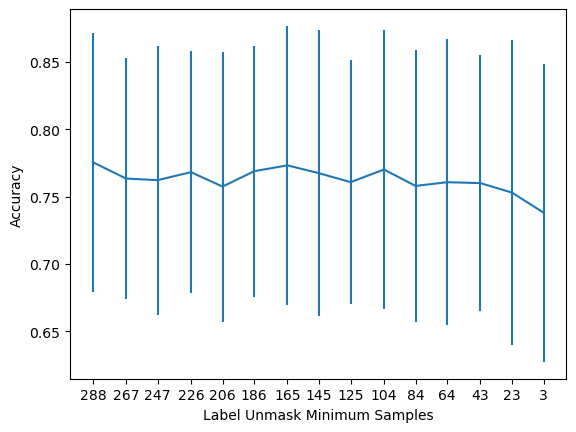

In [40]:
accuracy_score, rf, source_score, source_size, X_tests, y_tests = rfwrap.msl_errorbars_kfold_data(
    n_folds = 10,
    n_estimators=300, 
    n_forests=15,
    data = data,
    parameters=parameters, 
    metric = "auc", 
    plot=True)

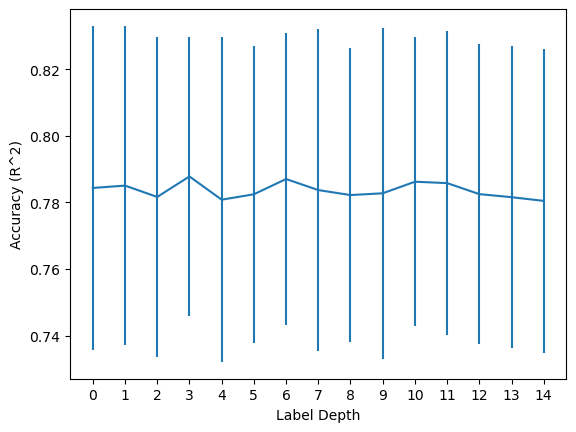

In [31]:
accuracy_score, rf, source_score, source_size, X_tests, y_tests = rfwrap.errorbars_kfold_data(
    n_folds = 10,
    n_estimators=300, 
    depth=15,
    data = data,
    parameters=parameters, 
    metric = "auc", 
    plot=True)